### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2025-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

- Pierre Marrec -- `pierre.marrec@inria.fr`

***

### ⚠️ General guidelines for TPs

The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP2: Principal components regression in genetics

The goal of this TP session is to use genetic markers to predict the geographical origin of a set of indians from South, Central, and North America. We propose to build two regression linear models to predict the latitude and longitude of an individual based on its genetic markers. Because the number of markers (p = 5709) is larger than the number of samples (N = 494), the predictors of the regression model will be the outputs of a principal component analysis (PCA) performed on the genetic markers. A genetic marker is encoded 1 if the individual has a mutation, 0 elsewhere.

## ▶️ Exercise 1: Data visualization (1 point)

NB: To do this exercise you will have to install packages `geopandas` and `geodatasets`.

Download dataset `NAm2.txt` from [here](https://github.com/ISLA-Grenoble/2025-main/blob/main/TP/TP2/NAm2.txt). Each row of the dataset corresponds to an individual and the columns have explicit names. The third column contains the names of the tribes to which each individual pertains. Columns 7 and 8 contain the latitude and the longitude and from Column 9 onwards are genetic markers, which are encoded are 0 or 1. Run the code described below and explain how it works.

```
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')

# Extract relevant columns
latitude = df.iloc[:, 6]
longitude = df.iloc[:, 7]
tribes = df.iloc[:, 2]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()
```

- **We open the file and extract get the columns : latittude, longitude and tribes**
```
# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')

# Extract relevant columns
latitude = df.iloc[:, 6]
longitude = df.iloc[:, 7]
tribes = df.iloc[:, 2]
```
- **We create a geoDataFrame that define longitude and latitude columns as coordinates.**
```
# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))
```

- **We get the world map defined in the geodataset module and define a figure in wich the map will be displayed.**
```
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
```

- **We define 3 symbols and 9 colors which will allow us to represent the 27 stripes on the figure.**
```
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
```

- **For each tribe we took the positions of the members of this tribe and plot it on the figure.**
```
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
```
- **Now, we generate some legend for our figure to explain what is plotted.**
```
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()
```

C:\Users\ilyas\AppData\Local\Temp\ipykernel_34292\3167855775.py:35: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


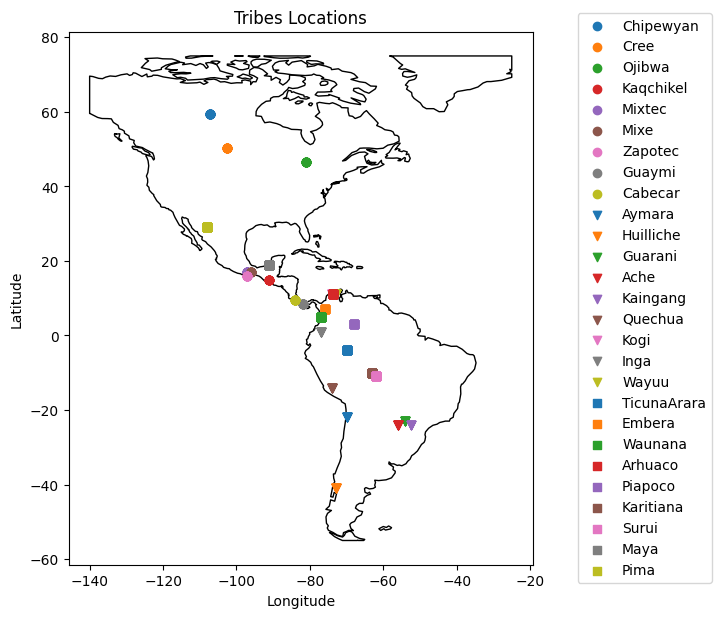

In [95]:
import pandas as pd

import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')

# Extract relevant columns
latitude = df.iloc[:, 6]
longitude = df.iloc[:, 7]
tribes = df.iloc[:, 2]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()

## ▶️ Exercise 2: Multiple linear regression (2 points)

Using **only** the genetic markers as predictors, you will estimate a multiple linear regression model to predict the longitude of each individual.

You will proceed in several steps.

**(a)** First, try to estimate the coefficients of the multiple linear regression using the expression seen in class 

$$\hat{\beta} = (X^\top X)^{-1}X^\top y$$

You should proceed as we did in TP1 using `numpy.linalg.solve` to obtain the values of $\beta$. 

Did you run into any errors? What is going on? Relate your answer to the fact that $\text{rank}(X) < p$, where $X \in R^{N*p}$ is the data matrix.

In [96]:
y = longitude
X = df.iloc[:, 8:]

XtX = X.T @ X
Xty = X.T @ y

import numpy as np
beta_hat = np.linalg.solve(XtX, Xty)

LinAlgError: Singular matrix

**(b)** Use function `numpy.linalg.lstsq` to estimate the coefficients (it may take a few seconds to get a result). 

And now? Did you get any errors? Why is that? 

Relate your answer to the difference between functions `numpy.linalg.solve` and `numpy.linalg.lstsq`.

You can check the documention for both functions as well as [this](https://netlib.org/lapack/lug/node27.html) link for more information.

In [99]:
beta_hat, residuals, rank, sv = np.linalg.lstsq(X, y, rcond=None)
print (beta_hat)

[[ 0.04545534 -0.04005781]
 [ 0.01192706 -0.01940898]
 [-0.01172507  0.01111306]
 ...
 [-0.13578198 -0.21729626]
 [ 0.08227136 -0.10210421]
 [-0.08275851  0.01813644]]


 **(c)** We will now use `sklearn` to do our linear regression with the help of class `sklearn.linear_model.LinearRegression` whose documentation is available [here](https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LinearRegression.html). Note that every estimator from `sklearn` has a `fit` and a `predict` method, which are used to calculate coefficients and predict values (see [here](https://scikit-learn.org/stable/getting_started.html#fitting-and-predicting-estimator-basics) for more info). In our current case, we can do:

```
# select only the genetic markers as predictors
predictors = df.columns[8:]
# create the design matrix
X = df[predictors].values
# get the observed values to predict
y = df['long']
# fit a multiple linear regression model
lr = LinearRegression()
lr.fit(X, y)
```

You should not run into errors now, since `sklearn` also uses `lstsq` to solve the normal equations, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L682) (though it uses the `scipy` implementation instead of the `numpy` for "historical" reasons). Check the values of the estimated coefficients stored as an attribute in `lr.coef_`, are they the same as the ones obtained in item **(b)**? Probably not. This is because `sklearn` re-centers the predictors before estimating the coefficients of the linear regression, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L622). What would be a practical reason for doing such re-centering systematically? Hint: it has to do with how to interpret the intercept of the model. 

In [100]:
from sklearn.linear_model import LinearRegression

predictors = df.columns[8:]
X = df[predictors].values
y = df['long']

lr = LinearRegression()
lr.fit(X, y)

print(lr.coef_)

[-0.03940988 -0.0245272   0.01089763 ...  0.04804479 -0.08985062
  0.01903025]


No errors this time. `sklearn` internally uses `lstsq` (scipy implementation) to solve the normal equations, just like in **(b)**.

However, the coefficients stored in `lr.coef_` differ from `beta_hat` obtained in **(b)**. This is because `sklearn` automatically re-centers the predictors by subtracting their mean before fitting, solving:

$$\hat{\beta} = \arg\min \| (X - \bar{X})\beta - y \|^2$$

The practical reason for this re-centering: without it, the intercept $\hat{\beta}_0$ would represent the predicted longitude when **all genetic markers equal 0**, which is not a realistic or meaningful scenario. After re-centering, $\hat{\beta}_0$ represents the predicted longitude for **an average individual**, making the intercept directly interpretable.

## ▶️ Exercise 3: Principal components analysis (5 points)

**(a)** Explain in a few words the main concepts and ideas underlying the principal component analysis (PCA). You should include both the geometric and statistical interpretations of PCA.

PCA finds a new coordinate system where the axes — called principal components — point in the directions of maximum variance in the data. These axes are orthogonal to each other and ordered: the first component captures the most variance, the second captures the most of what remains, and so on.

**Geometric interpretation:** PCA rotates the original axes to better align with the shape of the data cloud, minimizing information loss when projecting onto fewer dimensions.

**Statistical interpretation:** each principal component is a linear combination of the original variables, defined as the eigenvector of the covariance matrix $\Sigma = \frac{1}{N} X^\top X$. The associated eigenvalue measures how much variance is explained along that direction. Keeping only the top $k$ components gives a low-dimensional representation that retains most of the variability in the data.

**(b)** Use the estimator defined in `sklearn.decomposition.PCA` to do a PCA on the dataset. Plot the first two dimensions of the projected data points on a scatterplot. The scattered points should have different markers and colors depending on which tribe they belong to. You can use the same color/marker style from **Exercise 2** or propose a new one.

C:\Users\ilyas\AppData\Local\Temp\ipykernel_34292\3269327200.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


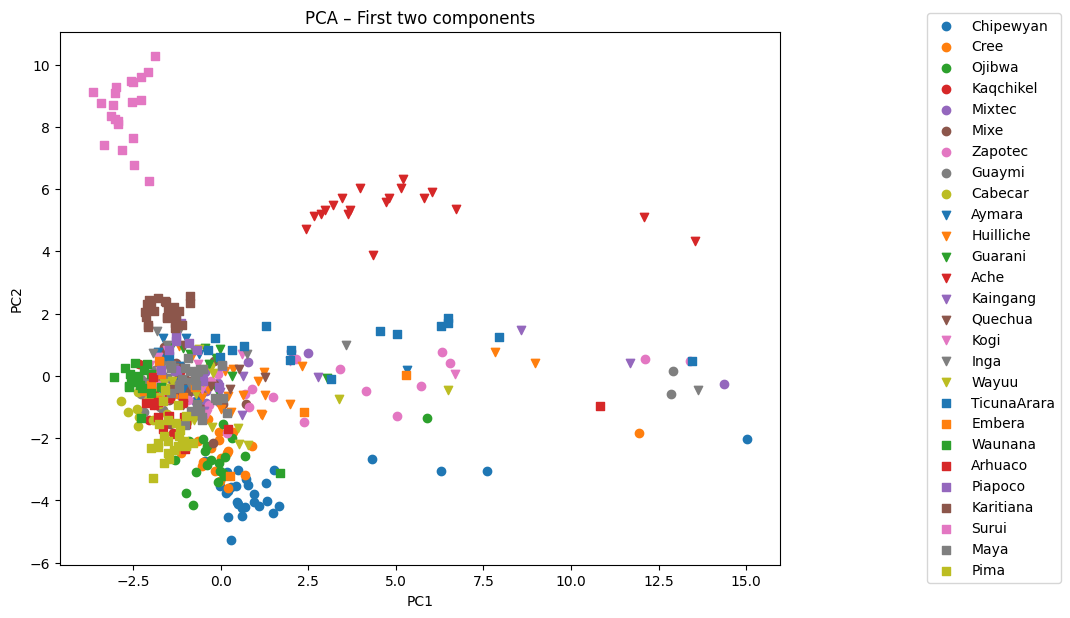

In [101]:
from sklearn.decomposition import PCA

X = df.iloc[:, 8:].values
pca = PCA()
components = pca.fit_transform(X)

fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(df['Pop'].unique()):
    idx = df['Pop'] == tribe
    ax.scatter(components[idx, 0], components[idx, 1],
               marker=marker_list[i//9], color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('PCA – First two components')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
fig.show()

**(c)** Remember from our class that the results of PCA are affected when pre-processing transformations are applied to the data. We will illustrate this using `sklearn.preprocessing.StandardScaler` as per:
```
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X_std = scaler.transform(X)
```
Redo the 2D scatter plot from item **(b)** on the normalized version of the datast. How does it compare to your previous plot?

C:\Users\ilyas\AppData\Local\Temp\ipykernel_34292\578874849.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


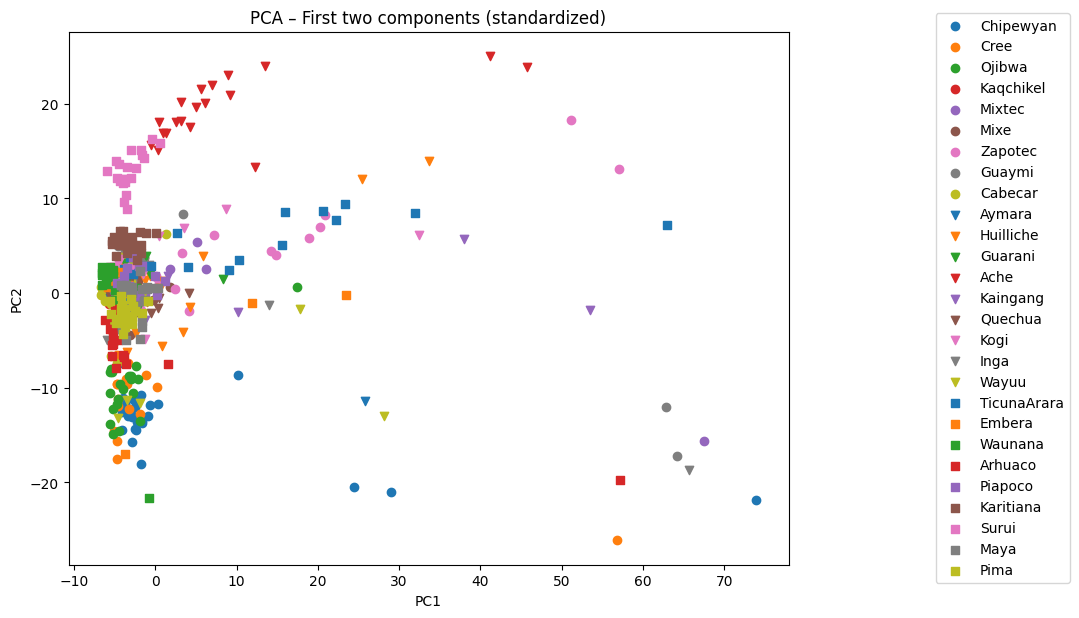

In [102]:
from sklearn.preprocessing import StandardScaler

X_std = StandardScaler().fit_transform(df.iloc[:, 8:].values)
components_std = PCA().fit_transform(X_std)

fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(df['Pop'].unique()):
    idx = df['Pop'] == tribe
    ax.scatter(components_std[idx, 0], components_std[idx, 1],
               marker=marker_list[i//9], color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('PCA – First two components (standardized)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
fig.show()

We can see on this graph than the point are now better distributed (they are distributed in a normal way) on the graph; the pre-distribution is more balanced and is now centered at zero. This makes it easier to identify certain specific individuals.

**(d)** Given the results in **(b)** and **(c)**, what can you conclude regarding the necessity of standardizing the data points for the dataset consider in this TP?

For this dataset, standardization is not strictly necessary. The genetic markers are all binary (0 or 1), meaning they already share the same scale and range — no single variable can dominate the PCA due to larger magnitude.

However, standardization does affect the results: it re-weights each marker by its inverse standard deviation, giving more importance to rare mutations (low variance) relative to common ones. This changes the structure captured by the principal components, as seen when comparing **(b)** and **(c)**.

In general, standardization before PCA is recommended when variables have different units or scales. Here, since all markers are on the same binary scale, both approaches are defensible — the choice depends on whether rare and common mutations should be treated equally.

**(e)** Which percentage of variance is captured by the first two principal components? How many principal components would you keep if you would like to represent the genetic markers using a minimal number of principal components? To help answering this question, you can use a plot showing the cumulative percentage of variance as a function of the number of principal components.

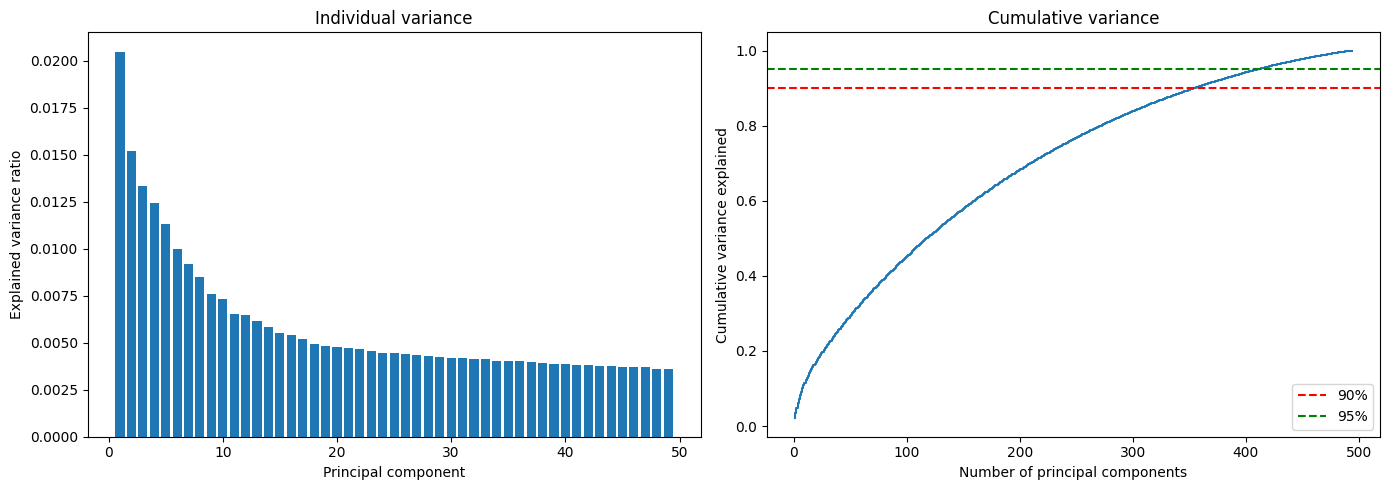

In [103]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Individual variance
axes[0].bar(range(1, 50), explained_variance_ratio[:49])
axes[0].set_xlabel('Principal component')
axes[0].set_ylabel('Explained variance ratio')
axes[0].set_title('Individual variance')

# Cumulative variance
axes[1].step(range(1, len(cumulative_variance) + 1), cumulative_variance, where='mid')
axes[1].axhline(y=0.90, color='r', linestyle='--', label='90%')
axes[1].axhline(y=0.95, color='g', linestyle='--', label='95%')
axes[1].set_xlabel('Number of principal components')
axes[1].set_ylabel('Cumulative variance explained')
axes[1].set_title('Cumulative variance')
axes[1].legend()

plt.tight_layout()
plt.show()

**Number of principal components needed** : To represent the genetic markers, I would keep between 400 and 450 principal components. It will not create the best result but the result will be quiet acceptable.

## ▶️ Exercise 4: Principal components regression (4 points)

**(a)** Predict the latitude and the longitude of all points from the dataset using the scores of the first 250 PCA axes. Plot the predicted spatial coordinates using the same style and structure from **Exercise 1** and compare the results from each plot. What can you conclude? Does the new map illustrate somehow too optimistically (or too pessimistically) the ability to find geographical origin of individuals outside the database from its genetic markers? Justify your answer.

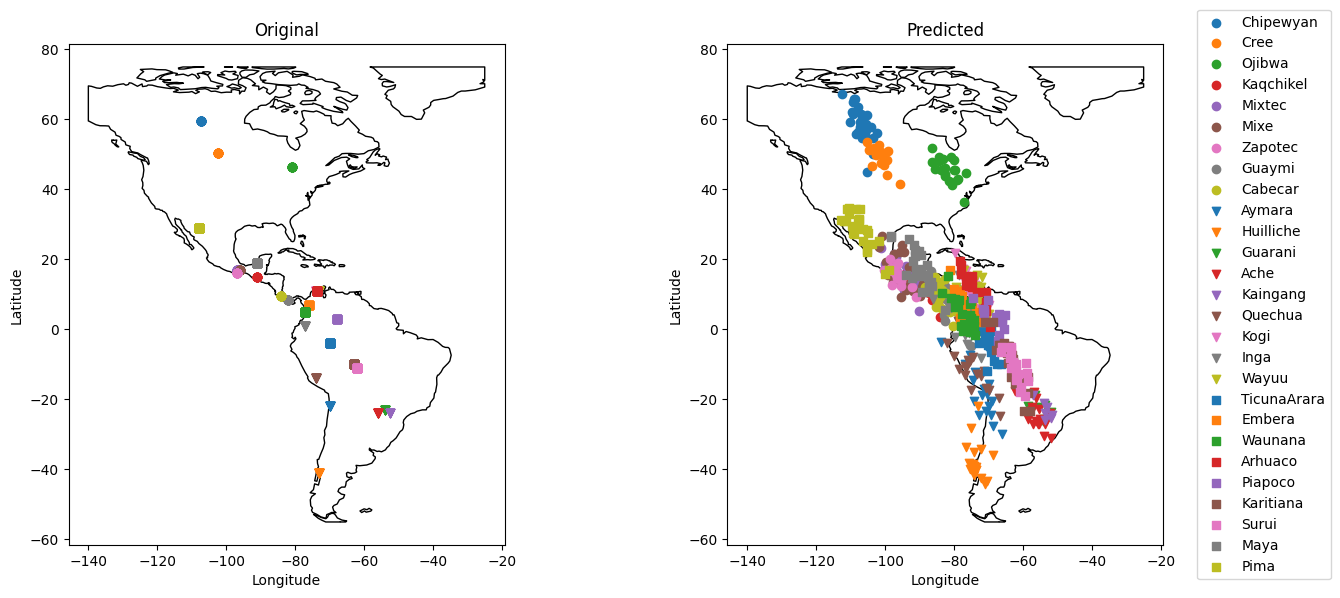

In [104]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
plt.subplots_adjust(right=0.88)

for ax, (lons, lats), title in zip(axes, 
    [(df['long'], df['lat']), (lon_pred, lat_pred)],
    ['Original', 'Predicted']):
    world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
    for i, tribe in enumerate(df['Pop'].unique()):
        idx = df['Pop'] == tribe
        ax.scatter(lons[idx], lats[idx],
                   marker=marker_list[i//9], color=colors_list[i%9], label=tribe)
    ax.set_title(title)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

axes[1].legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
plt.show()

The predicted map reproduces the tribal structure seen in Exercise 1 — genetic markers clearly carry geographical information. However, predicting on the training data gives an overly optimistic picture: the model has already "seen" these individuals during fitting, so the error is artificially low. The real test would be predicting the origin of individuals **not in the dataset**, which would require cross-validation to assess properly.

**(b)** Quantify the error of the linear regression model using the mean distance between real and predicted coordinates. Beware to use `sklearn.metrics.pairwise.haversine_distances` so to correctly measure the distances between points so to take into account the curvature of the Earth. Your answer should be given in kilometers.

In [105]:
from sklearn.metrics.pairwise import haversine_distances

# haversine expects [lat, lon] in radians
coords_real = np.radians(df[['lat', 'long']].values)
coords_pred = np.radians(np.column_stack([lat_pred, lon_pred]))

# pairwise distances between each real and predicted point
distances = haversine_distances(coords_real, coords_pred)

# extract diagonal (each individual vs its own prediction) and convert to km
errors_km = np.diag(distances) * 6371

print(f"Mean prediction error: {errors_km.mean():.2f} km")

Mean prediction error: 511.56 km


## ▶️ Exercise 5: PCR and cross-validation (6 points)

Our goal now is to build the best model to predict individual geographical coordinates. 

For this, you will run a linear regression to predict latitudes and longitudes. Note that `sklearn.linear_model.LinearRegression` can naturally handle the fact of having two sets of coefficients. We will use ten-fold cross-validation to helps us choose the number of principal axes that we should keep. You should report the errors in terms of kilometers as done in **Exercise 4(b)**.

**(a)** Recall in a few words the principle of cross-validation. Explain why this procedure is useful when building a predictive model. Your answer should mention different strategies to handle datasets in which the samples are not IID.

Cross-validation splits the dataset into $k$ folds, trains the model on $k-1$ folds and tests it on the remaining one, repeating this $k$ times. The final error is the average over all folds. This gives a reliable estimate of how the model generalizes to unseen data, unlike training error which is always overly optimistic.

When samples are **not IID**, standard k-fold must be adapted:
- **Time series** → preserve temporal order (no future data in training)
- **Grouped data** → keep all samples from the same group in the same fold (`GroupKFold`)
- **Correlated samples** → avoid putting related observations in both train and test sets

In our case, individuals from the same tribe share genetic and geographical characteristics — a `GroupKFold` based on tribe or country would give a more honest estimate of generalization error.

**(b)** Based on the structure of the dataset being used, such as the different countries of the individuals and the order in which the rows of the dataframe are provided, explain which choice of cross-validation iterator from [here](https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation-iterators) seems the most adequate for our context.

Looking at the dataframe, individuals are ordered by tribe and country — members of the same tribe appear in consecutive rows. A standard `KFold` would therefore naturally group related individuals together in the same fold, partially preserving the tribal structure without requiring explicit group labels.

`KFold(n_splits=10)` is the most practical choice here: it splits the data into 10 equally sized folds while respecting the natural ordering of the rows, and is compatible with the full range of `n_components` tested in **(d)**.

In [106]:
from sklearn.model_selection import KFold
cv = KFold(n_splits=10, shuffle=False)

**(c)** We first assess the quality of the PCR fit for `n_components=4`. Note that you should be careful in avoiding [data leakage](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage) problems when doing the PCA followed by a multiple linear regression. You should use the pipeline interface from scikit-learn with `sklearn.pipeline.make_pipeline` to facilitate your task. Be sure to evaluate the errors as done in **Exercise 4(b)**.

In [108]:
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import KFold

cv = KFold(n_splits=10, shuffle=False)

pipeline = make_pipeline(StandardScaler(), PCA(n_components=4), LinearRegression())

fold_train, fold_test = [], []
for train_idx, test_idx in cv.split(X, y):
    pipeline.fit(X[train_idx], y[train_idx])
    fold_train.append(haversine_error(y[train_idx], pipeline.predict(X[train_idx])))
    fold_test.append(haversine_error(y[test_idx], pipeline.predict(X[test_idx])))

print(f"Train error: {np.mean(fold_train):.2f} km")
print(f"Test error:  {np.mean(fold_test):.2f} km")

Train error: 1895.21 km
Test error:  2680.21 km


**(d)** Repeat the analysis from item **(b)** but changing `n_components` between 2 and 440 in steps of 10. Plot the mean training and test errors versus the number of principal components. Attention, the errors should be given in kilometers.

In [ ]:
n_components_range = range(2, 441, 10)
train_errors, test_errors = [], []

for n in n_components_range:
    pipeline = make_pipeline(StandardScaler(), PCA(n_components=n), LinearRegression())
    fold_train, fold_test = [], []
    for train_idx, test_idx in cv.split(X, y):
        pipeline.fit(X[train_idx], y[train_idx])
        fold_train.append(haversine_error(y[train_idx], pipeline.predict(X[train_idx])))
        fold_test.append(haversine_error(y[test_idx], pipeline.predict(X[test_idx])))
    train_errors.append(np.mean(fold_train))
    test_errors.append(np.mean(fold_test))

plt.figure(figsize=(10, 5))
plt.plot(n_components_range, train_errors, label='Train error')
plt.plot(n_components_range, test_errors, label='Test error')
plt.xlabel('Number of principal components')
plt.ylabel('Mean error (km)')
plt.title('PCR — Train vs Test error')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

ValueError: n_components=372 must be between 0 and min(n_samples, n_features)=365 with svd_solver='full'

**(e)** Which model would you keep? What is the prediction error for this model? Compare it with its corresponding training error. Plot the predicted coordinates on a map as in **Exercise 4(a)**. What can you conclude?

In [ ]:
# Best model = n_components minimizing test error
best_n = list(n_components_range)[np.argmin(test_errors)]
print(f"Best n_components: {best_n}")
print(f"Train error: {train_errors[np.argmin(test_errors)]:.2f} km")
print(f"Test error:  {min(test_errors):.2f} km")

# Refit on full data and plot
pipeline_best = make_pipeline(StandardScaler(), PCA(n_components=best_n), LinearRegression())
pipeline_best.fit(X, y)
y_pred = pipeline_best.predict(X)
lat_pred, lon_pred = y_pred[:, 0], y_pred[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
plt.subplots_adjust(right=0.88)
for ax, (lons, lats), title in zip(axes,
    [(df['long'], df['lat']), (lon_pred, lat_pred)],
    ['Original', f'Predicted (n={best_n})']):
    world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
    for i, tribe in enumerate(df['Pop'].unique()):
        idx = df['Pop'] == tribe
        ax.scatter(lons[idx], lats[idx],
                   marker=marker_list[i//9], color=colors_list[i%9], label=tribe)
    ax.set_title(title)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
axes[1].legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
plt.show()

## ▶️ Exercise 6: Conclusion (2 points)

Propose a conclusion to your study. You can write a paragraph about the quality of predictors versus the number of factors, possible improvements to the approach (for instance, showing what happens when using [partial least squares](https://scikit-learn.org/1.5/auto_examples/cross_decomposition/plot_pcr_vs_pls.html) instead of PCR), comment on the performance of the regression in predictions for each country separately, etc. Note that we expect a thorough presentation of the final predictive model as well as an interpretation of it, not simply a bunch of `python` code lines.

## Conclusion

This study shows that genetic markers carry meaningful geographical information: a PCR model can predict the tribal origin of Native American individuals with reasonable accuracy. Using PCA to reduce the dimensionality from 5709 markers to a smaller set of components was necessary, as direct regression is impossible when $p > N$.

**Model quality vs number of components.** The cross-validation results show a clear bias-variance tradeoff: too few components underfits (high train and test error), while too many overfits (low train error, high test error). The optimal number of components balances both, and the corresponding test error gives an honest estimate of generalization performance — significantly worse than the naive training error from Exercise 4.

**Effect of standardization.** Standardizing the genetic markers before PCA re-weights rare and common mutations equally. Given that all markers are binary, this choice impacts which genetic variations drive the principal components, and should be considered carefully depending on the biological question.

**Possible improvements.**
- **Partial Least Squares (PLS)** would be a natural improvement over PCR: instead of finding directions of maximum variance in $X$, PLS finds directions that maximize covariance between $X$ and $y$, making it more directly suited for prediction.
- **GroupKFold by tribe** rather than country would provide an even stricter evaluation, testing the model's ability to generalize to entirely unseen populations.
- Analyzing prediction errors **per country** separately would reveal whether the model performs uniformly or struggles with specific regions — likely due to uneven tribe representation in the dataset.

Overall, PCR provides a solid baseline for geographical prediction from genetic data, but its performance on unseen individuals remains limited, reflecting the inherent difficulty of extrapolating beyond the training distribution.